**Seeding for reproducibility**

In [2]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[]

In [3]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

**Importing the dependencies**

In [4]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

**GPU Configuration**

In [5]:
!python -m pip install --upgrade pip

In [6]:
pip install tensorflow-directml

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-directml (from versions: none)
ERROR: No matching distribution found for tensorflow-directml


**Data Curation**

Upload the kaggle.json file

In [7]:
!pip install kaggle

In [8]:
kaggle_credentails = json.load(open("kaggle.json"))

In [9]:
# setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [10]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p "D:/"

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
plantvillage-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [11]:
!ls

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [12]:
with ZipFile(r"D:\plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(r"D:/" \
    "")

In [14]:
# set this to wherever you extracted the ZIP (e.g. D:\ on Windows)
root_dir = r"D:\plantvillage dataset"  # adjust path if needed

print("root_dir:", root_dir)
print("contents:", os.listdir(root_dir))

for sub in ["segmented", "color", "grayscale"]:
    subdir = os.path.join(root_dir, sub)
    if os.path.isdir(subdir):
        files = os.listdir(subdir)
        print(f"{sub} → {len(files)} items, sample:", files[:5])
    else:
        print(f"❗ directory not found: {subdir!r}")

root_dir: D:\plantvillage dataset
contents: ['color', 'grayscale', 'segmented']
segmented → 38 items, sample: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
color → 38 items, sample: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
grayscale → 38 items, sample: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


**Number of Classes = 38**

In [15]:
# Example check using root_dir defined earlier
healthy_dir = os.path.join(root_dir, "color", "Grape___healthy")
if os.path.isdir(healthy_dir):
    print(len(os.listdir(healthy_dir)))
    print(os.listdir(healthy_dir)[:5])
else:
    print(f"❗ directory not found: {healthy_dir!r}")

423
['00e00912-bf75-4cf8-8b7d-ad64b73bea5f___Mt.N.V_HL 6067.JPG', '0163a6aa-fbf8-47c5-965f-59b6efe8bfe5___Mt.N.V_HL 6103.JPG', '0294ca65-4c29-44be-af28-501df9f715e8___Mt.N.V_HL 6176.JPG', '02f95acb-5d92-4f2a-b7ec-3af8709ee7c9___Mt.N.V_HL 9078.JPG', '03027791-26bb-4c46-960e-8df76e27042c___Mt.N.V_HL 6070.JPG']


**Data Preprocessing**

In [16]:
# Dataset Path
base_dir = 'plantvillage dataset/color'

(256, 256, 3)


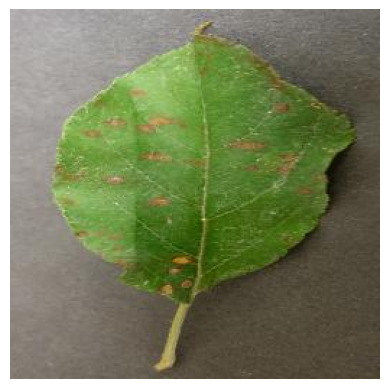

In [17]:
# Dataset Path
base_dir = os.path.join(root_dir, 'color')

# pick a sample image relative path
sample_rel = os.path.join(
    "color", "Apple___Cedar_apple_rust",
    "025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG"
)
image_path = os.path.join(root_dir, sample_rel)

# Read the image only if it exists
if not os.path.isfile(image_path):
    print("❗ file not found:", image_path)
else:
    img = mpimg.imread(image_path)
    print(img.shape)
    # Display the image
    plt.imshow(img)
    plt.axis('off')  # Turn off axis numbers
    plt.show()

In [18]:
# try reading the same sample image and print pixel array if found
sample_rel = os.path.join(
    "color", "Apple___Cedar_apple_rust",
    "025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG"
)
image_path = os.path.join(root_dir, sample_rel)

if not os.path.isfile(image_path):
    print("❗ file not found:", image_path)
else:
    # Read the image
    img = mpimg.imread(image_path)
    print(img)

[[[179 175 176]
  [181 177 178]
  [184 180 181]
  ...
  [115 112 105]
  [108 105  98]
  [101  98  91]]

 [[176 172 173]
  [177 173 174]
  [178 174 175]
  ...
  [113 110 103]
  [111 108 101]
  [109 106  99]]

 [[180 176 177]
  [180 176 177]
  [180 176 177]
  ...
  [108 105  98]
  [111 108 101]
  [114 111 104]]

 ...

 [[137 128 119]
  [131 122 113]
  [125 116 107]
  ...
  [ 74  65  48]
  [ 74  65  48]
  [ 73  64  47]]

 [[136 127 118]
  [132 123 114]
  [128 119 110]
  ...
  [ 77  69  50]
  [ 75  67  48]
  [ 75  67  48]]

 [[133 124 115]
  [133 124 115]
  [132 123 114]
  ...
  [ 81  73  54]
  [ 80  72  53]
  [ 79  71  52]]]


In [19]:
# Image Parameters
img_size = 224
batch_size = 32

**Train Test Split**

In [20]:
# Image Data Generators with Enhanced Augmentation
from tensorflow.keras.applications.resnet50 import preprocess_input

data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [21]:
# Train Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [22]:
# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


**Convolutional Neural Network**

In [23]:
# Model Definition using Transfer Learning (ResNet50)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [24]:
# model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,130,214 (92.05 MB)

 Trainable params: 538,406 (2.05 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [25]:
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**Model training**

In [27]:
history = model.fit(
    train_generator,
    steps_per_epoch=300,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=80,
    callbacks=[early_stop]
)

Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 677s 2s/step - accuracy: 0.4913 - loss: 2.0326 - val_accuracy: 0.8047 - val_loss: 0.8856
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 0.7668 - loss: 0.8486 - val_accuracy: 0.8855 - val_loss: 0.4331
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 396s 1s/step - accuracy: 0.8329 - loss: 0.5766 - val_accuracy: 0.9227 - val_loss: 0.3044
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 375s 1s/step - accuracy: 0.8629 - loss: 0.4620 - val_accuracy: 0.9273 - val_loss: 0.2508
Epoch 5/15
158/300 ━━━━━━━━━━━━━━━━━━━━ 2:19 980ms/step - accuracy: 0.8725 - loss: 0.4239

d:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


300/300 ━━━━━━━━━━━━━━━━━━━━ 233s 776ms/step - accuracy: 0.8795 - loss: 0.3980 - val_accuracy: 0.9395 - val_loss: 0.2244
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.8963 - loss: 0.3405 - val_accuracy: 0.9414 - val_loss: 0.2034
Epoch 7/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 453s 2s/step - accuracy: 0.9033 - loss: 0.3225 - val_accuracy: 0.9410 - val_loss: 0.1932
Epoch 8/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 420s 1s/step - accuracy: 0.9161 - loss: 0.2764 - val_accuracy: 0.9531 - val_loss: 0.1667
Epoch 9/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.9178 - loss: 0.2660 - val_accuracy: 0.9582 - val_loss: 0.1418
Epoch 10/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 230s 766ms/step - accuracy: 0.9146 - loss: 0.2761 - val_accuracy: 0.9566 - val_loss: 0.1380
Epoch 11/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 373s 1s/step - accuracy: 0.9241 - loss: 0.2391 - val_accuracy: 0.9645 - val_loss: 0.1194
Epoch 12/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - accuracy: 0.9361 - loss: 0.2071 - val_accura

**Model Evaluation**

In [28]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 321s 947ms/step - accuracy: 0.9652 - loss: 0.1052
Validation Accuracy: 96.52%


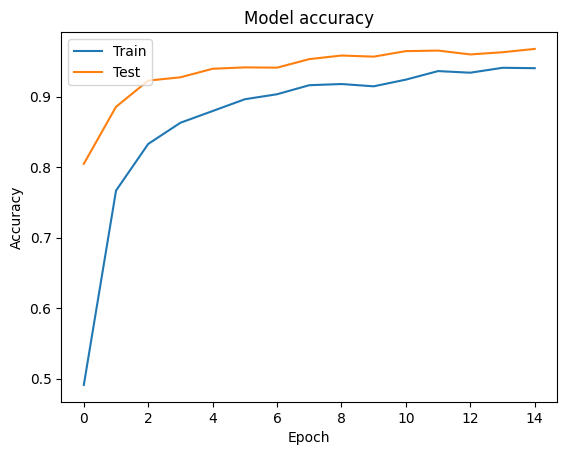

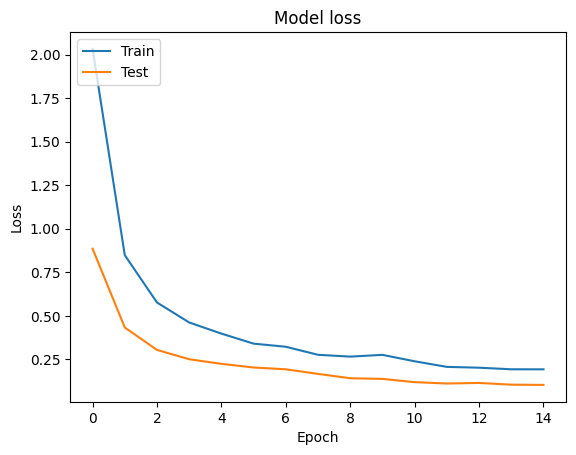

In [29]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

**Building a Predictive System**

In [30]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [31]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [32]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [33]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [36]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

def predict_image_class(model, image_path, class_indices):

    img = image.load_img(image_path, target_size=(224,224))
    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    # Important for ResNet50
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)

    predicted_index = np.argmax(prediction)

    class_labels = list(class_indices.keys())

    return class_labels[predicted_index]

In [40]:
# Example Usage
# Example Usage
image_path = "test_images/test_apple_black_rot.jpg"

predicted_class_name = predict_image_class(
    model,
    image_path,
    train_generator.class_indices
)

print("Predicted Class Name:", predicted_class_name)

FileNotFoundError: [Errno 2] No such file or directory: 'test_images/test_apple_black_rot.jpg'

**Save the model to Google drive or local**

In [35]:
model.save(r'D:\plant_disease_prediction_model1.h5')